## ***Healthy Life Style Data***

In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("/content/health lifestyle data FINAL.csv")

In [5]:
df.head()

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Smoker,Exercise_Freq,Diet_Quality,Alcohol_Consumption,Chronic_Disease,Stress_Level,Sleep_Hours
0,1,56,Other,177.6,37.3,11.8,Yes,NaN,Poor,NaN,No,9,8.5
1,2,69,Other,169.3,70.7,24.7,No,1-2 times/week,Good,High,No,2,5.9
2,3,46,Female,159.1,69.0,27.3,No,Daily,Excellent,Moderate,No,3,4.8
3,4,32,Male,170.6,76.4,26.3,No,3-5 times/week,Excellent,Moderate,No,9,6.6
4,5,60,Male,158.4,60.4,24.1,No,3-5 times/week,Excellent,Low,Yes,6,6.1


In [6]:
df.describe()

,ID,Age,Height_cm,Weight_kg,BMI,Stress_Level,Sleep_Hours
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,3750.500000,43.653333,164.948347,70.028587,26.025027,5.591867,7.002933
std,2165.207842,14.911816,9.963574,14.760003,6.419477,2.865983,1.514014
min,1.000000,18.000000,124.500000,12.800000,6.500000,1.000000,1.900000
25%,1875.750000,31.000000,158.100000,59.900000,21.600000,3.000000,6.000000
50%,3750.500000,43.000000,164.900000,70.100000,25.600000,6.000000,7.000000
75%,5625.250000,57.000000,171.600000,80.100000,30.100000,8.000000,8.000000
max,7500.000000,69.000000,197.000000,128.500000,56.800000,10.000000,12.600000


In [7]:
df.shape


(7500, 13)

In [8]:
df.isnull().sum()

,0
ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
BMI,0
Smoker,0
Exercise_Freq,1879
Diet_Quality,0
Alcohol_Consumption,1892


In [9]:
df["Exercise_Freq"] = df["Exercise_Freq"].fillna("Unknown")
df

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Smoker,Exercise_Freq,Diet_Quality,Alcohol_Consumption,Chronic_Disease,Stress_Level,Sleep_Hours
0,1,56,Other,177.6,37.3,11.8,Yes,Unknown,Poor,NaN,No,9,8.5
1,2,69,Other,169.3,70.7,24.7,No,1-2 times/week,Good,High,No,2,5.9
2,3,46,Female,159.1,69.0,27.3,No,Daily,Excellent,Moderate,No,3,4.8
3,4,32,Male,170.6,76.4,26.3,No,3-5 times/week,Excellent,Moderate,No,9,6.6
4,5,60,Male,158.4,60.4,24.1,No,3-5 times/week,Excellent,Low,Yes,6,6.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,7496,55,Other,168.3,52.4,18.5,Yes,1-2 times/week,Average,Moderate,Yes,4,5.5
7496,7497,24,Male,179.1,58.8,18.3,No,3-5 times/week,Excellent,Moderate,No,5,7.6
7497,7498,61,Other,160.2,80.0,31.2,No,3-5 times/week,Poor,Moderate,No,5,6.2
7498,7499,40,Female,172.6,66.1,22.2,No,1-2 times/week,Good,Low,No,9,6.1


In [10]:
df["Alcohol_Consumption"] = df["Alcohol_Consumption"].fillna("Unknown")
df

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Smoker,Exercise_Freq,Diet_Quality,Alcohol_Consumption,Chronic_Disease,Stress_Level,Sleep_Hours
0,1,56,Other,177.6,37.3,11.8,Yes,Unknown,Poor,Unknown,No,9,8.5
1,2,69,Other,169.3,70.7,24.7,No,1-2 times/week,Good,High,No,2,5.9
2,3,46,Female,159.1,69.0,27.3,No,Daily,Excellent,Moderate,No,3,4.8
3,4,32,Male,170.6,76.4,26.3,No,3-5 times/week,Excellent,Moderate,No,9,6.6
4,5,60,Male,158.4,60.4,24.1,No,3-5 times/week,Excellent,Low,Yes,6,6.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,7496,55,Other,168.3,52.4,18.5,Yes,1-2 times/week,Average,Moderate,Yes,4,5.5
7496,7497,24,Male,179.1,58.8,18.3,No,3-5 times/week,Excellent,Moderate,No,5,7.6
7497,7498,61,Other,160.2,80.0,31.2,No,3-5 times/week,Poor,Moderate,No,5,6.2
7498,7499,40,Female,172.6,66.1,22.2,No,1-2 times/week,Good,Low,No,9,6.1


In [11]:
df.isnull().sum()

,0
ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
BMI,0
Smoker,0
Exercise_Freq,0
Diet_Quality,0
Alcohol_Consumption,0


In [12]:
dup = df[df.duplicated(keep="first")]
len(dup)

0

In [13]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['Gender', 'Smoker', 'Exercise_Freq', 'Diet_Quality',
       'Alcohol_Consumption', 'Chronic_Disease'],
      dtype='object')

In [14]:
data_clean = df.copy()

for col in cat_cols:
    data_clean[col].astype(str).str.strip().str.title()

In [15]:
data_clean = data_clean.replace({

    "Gender": {
        "M": "Male",
        "F": "Female"
    },

    "Smoker": {
        "Yes ": "Yes",
        "Y": "Yes",
        "Nope": "No",
        "N": "No"
    },

    "Exercise_Freq": {
        "None": "Never",
        "No Exercise": "Never",
        "Everyday": "Daily",
        "Daily Exercise": "Daily",
        "Occasionally": "Sometimes"
    },

    "Diet_Quality": {
        "Poor Diet": "Poor",
        "Avg": "Average",
        "Good Diet": "Good"
    },

    "Alcohol_Consumption": {
        "Never Drink": "Never",
        "Occasional": "Sometimes",
        "Daily Drinking": "Daily"
    },

    "Chronic_Disease": {
        "None": "No",
        "Nil": "No",
        "Has Disease": "Yes"
    }
})


In [16]:
df.head(10)

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Smoker,Exercise_Freq,Diet_Quality,Alcohol_Consumption,Chronic_Disease,Stress_Level,Sleep_Hours
0,1,56,Other,177.6,37.3,11.8,Yes,Unknown,Poor,Unknown,No,9,8.5
1,2,69,Other,169.3,70.7,24.7,No,1-2 times/week,Good,High,No,2,5.9
2,3,46,Female,159.1,69.0,27.3,No,Daily,Excellent,Moderate,No,3,4.8
3,4,32,Male,170.6,76.4,26.3,No,3-5 times/week,Excellent,Moderate,No,9,6.6
4,5,60,Male,158.4,60.4,24.1,No,3-5 times/week,Excellent,Low,Yes,6,6.1
5,6,25,Female,167.7,62.0,22.0,No,Daily,Good,Moderate,No,1,5.8
6,7,38,Other,152.5,88.0,37.8,No,1-2 times/week,Good,High,Yes,2,5.8
7,8,56,Male,165.3,65.0,23.8,No,Daily,Good,Moderate,No,7,6.8
8,9,36,Male,176.9,41.3,13.2,No,Daily,Average,Unknown,No,6,6.3
9,10,40,Other,162.0,77.4,29.5,Yes,1-2 times/week,Good,Low,Yes,1,5.6


In [18]:
gender_stats = df.groupby('Gender').agg(
    Count=('BMI', 'count'),
    Avg_BMI=('BMI', 'mean'),
    Avg_Stress=('Stress_Level', 'mean')
).reset_index()

print(gender_stats)

   Gender  Count    Avg_BMI  Avg_Stress
0  Female   2510  26.025498    5.616733
1    Male   2551  26.098550    5.650725
2   Other   2439  25.947642    5.504715


In [20]:
exercise_stats = df.groupby('Exercise_Freq').agg(
    Count=('BMI', 'count'),
    Avg_BMI=('BMI', 'mean'),
    Avg_Stress=('Stress_Level', 'mean')
).reset_index()

print(exercise_stats)

    Exercise_Freq  Count    Avg_BMI  Avg_Stress
0  1-2 times/week   1869  25.975174    5.588550
1  3-5 times/week   1827  26.069184    5.521073
2           Daily   1925  25.824052    5.677403
3         Unknown   1879  26.237573    5.576370


In [22]:


# Load dataset
data = pd.read_csv("/content/health lifestyle data FINAL.csv")

# Create Age Groups
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['Teen', '20–30', '30–40', '40–50', '50–60', 'Senior']
data['Age_Group'] = pd.cut(data['Age'], bins=bins, labels=labels)

# Group and aggregate
age_stats = data.groupby('Age_Group').agg(
    Count=('BMI', 'count'),
    Avg_BMI=('BMI', 'mean'),
    Avg_Stress=('Stress_Level', 'mean'),
    Avg_Sleep=('Sleep_Hours', 'mean')
).reset_index()

print(age_stats)


  Age_Group  Count    Avg_BMI  Avg_Stress  Avg_Sleep
0      Teen    418  25.958852    5.775120   7.011962
1     20–30   1406  25.825462    5.553343   7.009673
2     30–40   1470  26.158095    5.512925   7.030680
3     40–50   1452  26.288085    5.533058   6.982507
4     50–60   1421  25.801478    5.617171   6.968332
5    Senior   1333  26.061290    5.699175   7.021530


/tmp/ipykernel_920/2468016499.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = data.groupby('Age_Group').agg(


In [23]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 50, 100],
    labels=['Teen', 'Young Adult', 'Middle Age', 'Senior']
)

In [24]:
import pandas as pd
import plotly.express as px

Bar Chart – Diet Quality vs Average BMI

In [25]:
diet_bmi = df.groupby('Diet_Quality').agg(
    Avg_BMI=('BMI', 'mean'),
    People=('BMI', 'count')
).reset_index()

fig1 = px.bar(
    diet_bmi,
    x='Diet_Quality',
    y='Avg_BMI',
    title='Average BMI by Diet Quality',
    color='Avg_BMI',
    hover_data=['People']
)

fig1.show()


 Bar Chart – Exercise Frequency vs Average Stress Level

In [26]:
exercise_stress = df.groupby('Exercise_Freq').agg(
    Avg_Stress=('Stress_Level', 'mean'),
    People=('Stress_Level', 'count')
).reset_index()

fig2 = px.bar(
    exercise_stress,
    x='Exercise_Freq',
    y='Avg_Stress',
    title='Average Stress Level by Exercise Frequency',
    color='Avg_Stress',
    hover_data=['People']
)

fig2.show()


In [27]:
diet_dist = df['Diet_Quality'].value_counts().reset_index()
diet_dist.columns = ['Diet_Quality', 'Count']

fig4 = px.pie(
    diet_dist,
    names='Diet_Quality',
    values='Count',
    title='Diet Quality Distribution'
)

fig4.show()


In [28]:

age_group_stress = df.groupby(
    'Age_Group',
    observed=False
).agg(
    Avg_Stress=('Stress_Level', 'mean')
).reset_index()




In [29]:
age_stress = df.groupby('Age_Group', observed=False).agg(
    Avg_Stress=('Stress_Level', 'mean')
).reset_index()

fig4 = px.bar(
    age_stress,
    x='Age_Group',
    y='Avg_Stress',
    title='Average Stress Level by Age Group',
    color='Avg_Stress'
)

fig4.show()


In [30]:
import plotly.express as px

age_stress = df.groupby('Age_Group', observed=False).agg(
    Avg_Stress=('Stress_Level', 'mean')
).reset_index()

fig = px.pie(
    age_stress,
    names='Age_Group',
    values='Avg_Stress',
    title='Average Stress Level by Age Group'
)

fig.show()


In [31]:
smoke_age = df.groupby(['Age_Group', 'Smoker'], observed=False).size().reset_index(name='Count')

fig5 = px.bar(
    smoke_age,
    x='Age_Group',
    y='Count',
    color='Smoker',
    title='Smoking Habit Across Age Groups'
)

fig5.show()


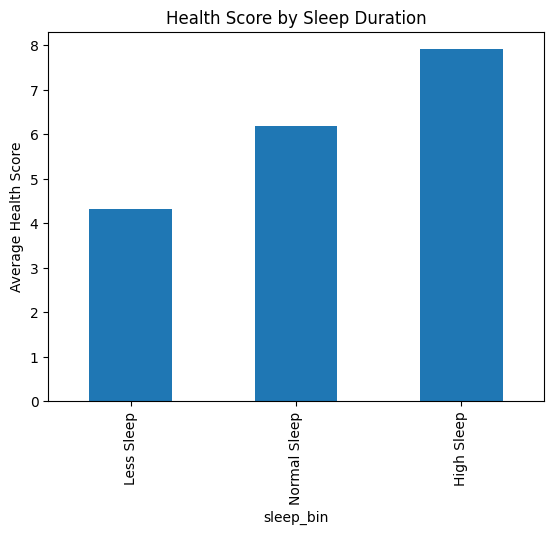

In [34]:
import matplotlib.pyplot as plt

df['sleep_bin'] = pd.cut(df['Sleep_Hours'],
                         bins=[0,5,7,9],
                         labels=['Less Sleep','Normal Sleep','High Sleep'])

df.groupby('sleep_bin', observed=False)['Sleep_Hours'].mean().plot(kind='bar')
plt.ylabel("Average Health Score")
plt.title("Health Score by Sleep Duration")
plt.show()

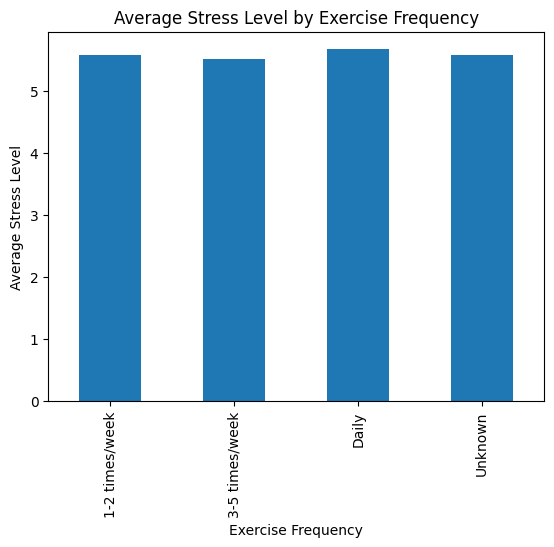

In [35]:
# Calculate average stress by exercise frequency
stress_exercise = df.groupby('Exercise_Freq')['Stress_Level'].mean()

# Plot bar chart
stress_exercise.plot(kind='bar')
plt.title("Average Stress Level by Exercise Frequency")
plt.xlabel("Exercise Frequency")
plt.ylabel("Average Stress Level")
plt.show()


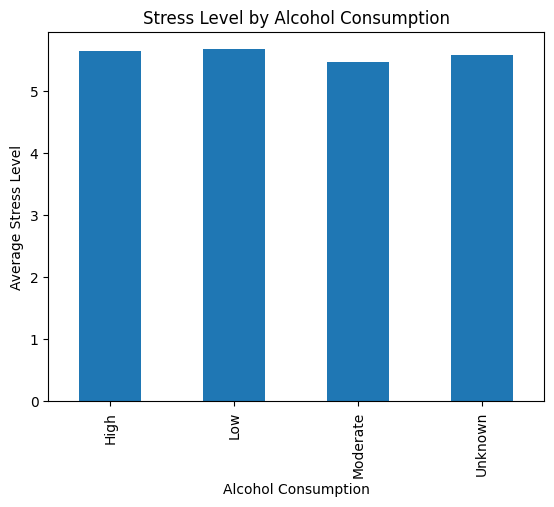

In [36]:
df.groupby('Alcohol_Consumption')['Stress_Level'].mean().plot(kind='bar')
plt.xlabel("Alcohol Consumption")
plt.ylabel("Average Stress Level")
plt.title("Stress Level by Alcohol Consumption")
plt.show()




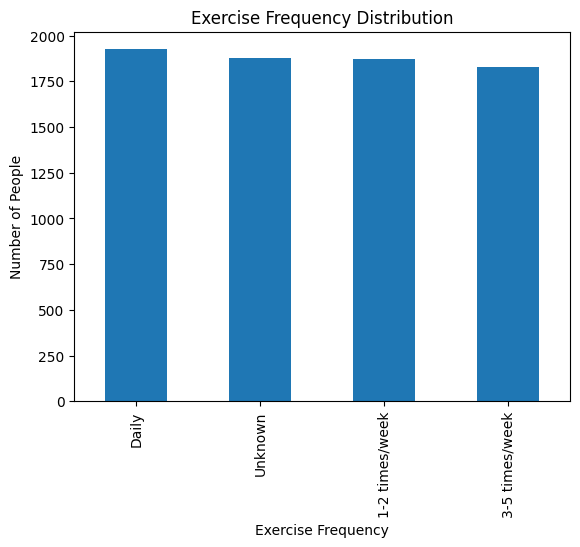

In [37]:
df['Exercise_Freq'].value_counts().plot(kind='bar')
plt.xlabel("Exercise Frequency")
plt.ylabel("Number of People")
plt.title("Exercise Frequency Distribution")
plt.show()


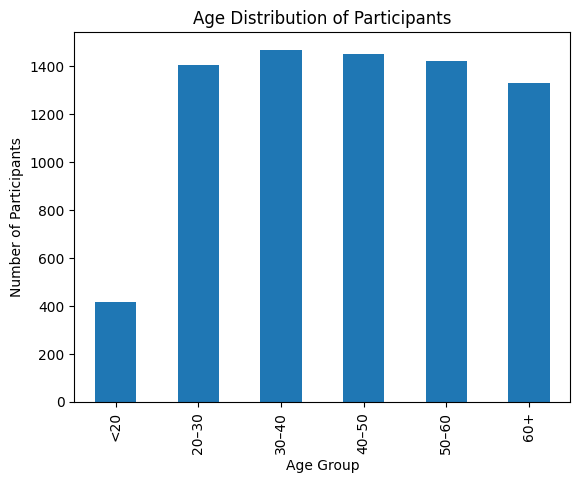

In [38]:
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20–30', '30–40', '40–50', '50–60', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Plot Age Distribution
df['Age_Group'].value_counts().sort_index().plot(kind='bar')
plt.title("Age Distribution of Participants")
plt.xlabel("Age Group")
plt.ylabel("Number of Participants")
plt.show()

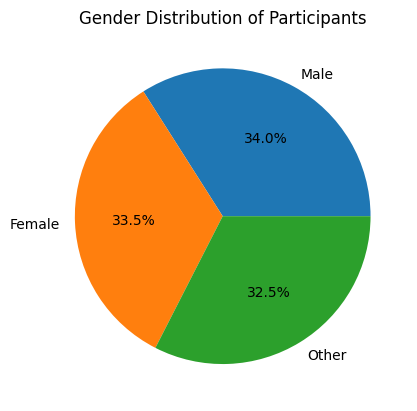

In [39]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution of Participants")
plt.ylabel("")
plt.show()


/tmp/ipykernel_920/515823079.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



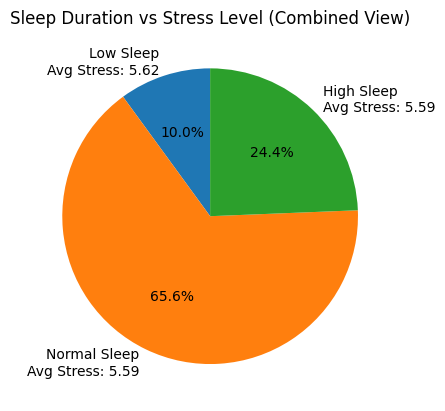

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Create sleep categories
data['Sleep_Category'] = pd.cut(
    data['Sleep_Hours'],
    bins=[0, 5, 8, 24],
    labels=['Low Sleep', 'Normal Sleep', 'High Sleep']
)

# Group by sleep category
sleep_stress = data.groupby('Sleep_Category').agg(
    Count=('Stress_Level', 'count'),
    Avg_Stress=('Stress_Level', 'mean')
).reset_index()

# Pie values
sizes = sleep_stress['Count']
labels = [
    f"{cat}\nAvg Stress: {round(stress,2)}"
    for cat, stress in zip(sleep_stress['Sleep_Category'], sleep_stress['Avg_Stress'])
]

plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sleep Duration vs Stress Level (Combined View)")
plt.show()



### **Conclusion:**
1. The project aims to analyze health and lifestyle data to understand factors affecting overall well-being.
2. Data was collected and cleaned, followed by exploratory data analysis using Pandas and visualization tools.
3. Key variables such as sleep duration, physical activity, and screen time were examined for patterns and correlations.
4. The analysis revealed meaningful relationships between healthy habits and improved health outcomes.
5. In conclusion, maintaining balanced lifestyle choices significantly contributes to better physical and mental health.

